# Import data as "hangry_df"

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from math import comb
from scipy.stats import ttest_ind, mannwhitneyu
from tqdm.notebook import tqdm

hangry_df = pd.read_excel("Supplementary_Table_S1.xlsx")

#print(hangry_df.to_string())
hangry_df

,Batch,Fight,Time,Aggression_Counts,Travel_Counts,Status
0,1.0,1.0,24.0,3,45.0,Starved
1,1.0,2.0,24.0,6,83.0,Starved
2,1.0,3.0,24.0,1,44.0,Starved
3,1.0,4.0,24.0,4,42.0,Starved
4,1.0,5.0,48.0,8,72.0,Starved
...,...,...,...,...,...,...
74,1.0,38.0,216.0,69,62.0,Fed
75,1.0,39.0,216.0,33,99.0,Fed
76,1.0,40.0,216.0,103,130.0,Fed
77,1.0,41.0,216.0,26,99.0,Fed


# Descriptive Statistics

In [2]:
# Descriptive summary table for observed aggression and travel counts

outcomes = {
    "Aggression_Counts": "Aggression counts",
    "Travel_Counts": "Travel counts"
}

descriptive_tables = []

for outcome, outcome_label in outcomes.items():

    summary = (
        hangry_df
        .groupby("Status")
        .agg(
            n_individuals=(outcome, "count"),
            n_fights=("Fight", "nunique"),  # change Fight_ID if your fight column has a different name
            mean=(outcome, "mean"),
            sd=(outcome, "std"),
            median=(outcome, "median"),
            q1=(outcome, lambda x: np.percentile(x.dropna(), 25)),
            q3=(outcome, lambda x: np.percentile(x.dropna(), 75)),
            minimum=(outcome, "min"),
            maximum=(outcome, "max")
        )
        .reset_index()
    )

    summary["Outcome"] = outcome_label
    descriptive_tables.append(summary)

descriptive_summary = pd.concat(descriptive_tables, ignore_index=True)

# Add IQR as a formatted column
descriptive_summary["IQR"] = (descriptive_summary["q1"].map("{:.2f}".format)+ "–"+ descriptive_summary["q3"].map("{:.2f}".format))

# Clean final table
descriptive_summary_table = (
    descriptive_summary[
        [
            "Outcome",
            "Status",
            "n_individuals",
            "n_fights",
            "mean",
            "sd",
            "median",
            "IQR",
            "minimum",
            "maximum"
        ]
    ]
    .rename(columns={
        "n_individuals": "n individuals",
        "n_fights": "n fights",
        "mean": "Mean",
        "sd": "SD",
        "median": "Median",
        "minimum": "Min",
        "maximum": "Max"
    })
)

# Display formatted table
display(
    descriptive_summary_table.style
    .format({
        "Mean": "{:.2f}",
        "SD": "{:.2f}",
        "Median": "{:.2f}",
        "Min": "{:.0f}",
        "Max": "{:.0f}"
    })
    .hide(axis="index")
)

# Save table
descriptive_summary_table.to_csv("descriptive_stats.csv",index=False)

#descriptive_summary_table

Outcome,Status,n individuals,n fights,Mean,SD,Median,IQR,Min,Max
Aggression counts,Fed,39,39,50.15,29.90,42.00,28.00–57.50,14,125
Aggression counts,Starved,39,39,21.64,23.64,15.00,5.50–24.50,1,98
Travel counts,Fed,39,39,92.82,39.44,93.00,63.50–129.00,9,175
Travel counts,Starved,39,39,81.13,37.97,78.00,48.50–107.00,32,191


# Define "balanced_subsample" and generate "one_sample_df"
- Draws one dataset with equal numbers of fed and starved individuals at each time point and all are from different fights 

In [3]:
# One Sample
rng = np.random.default_rng(1234)

def balanced_subsample(df, rng):
    sampled_groups = []

    for time_point, time_df in df.groupby("Time"):

        # Keep only fights that have both Starved and Fed available at this time point
        valid_fights = (time_df.groupby("Fight")["Status"].agg(lambda x: {"Starved", "Fed"}.issubset(set(x))))

        valid_fights = valid_fights[valid_fights].index.to_numpy()

        if len(valid_fights) < 2:
            continue

        # Randomly split valid fights into Starved-contributing and Fed-contributing fights
        shuffled_fights = rng.permutation(valid_fights)

        n_per_status = len(shuffled_fights) // 2

        starved_fights = shuffled_fights[:n_per_status]
        fed_fights = shuffled_fights[n_per_status:2 * n_per_status]

        sampled_starved = (time_df[(time_df["Fight"].isin(starved_fights)) &(time_df["Status"].eq("Starved"))].groupby("Fight", group_keys=False).sample(n=1, random_state=rng.integers(1_000_000)))

        sampled_fed = (time_df[(time_df["Fight"].isin(fed_fights)) &(time_df["Status"].eq("Fed"))].groupby("Fight", group_keys=False).sample(n=1, random_state=rng.integers(1_000_000)))

        sampled_groups.append(pd.concat([sampled_starved, sampled_fed], axis=0))

    one_sample_df = (pd.concat(sampled_groups, axis=0).sample(frac=1, random_state=rng.integers(1_000_000)).reset_index(drop=True))

    return one_sample_df


one_sample_df = balanced_subsample(hangry_df, rng)
#print (one_sample_df)

In [4]:
# Verify One Sample
balance_check = (
    one_sample_df
    .groupby(["Time", "Status"])
    .size()
    .unstack(fill_value=0)
    .rename_axis(columns=None)
    .reset_index()
)

print(balance_check)

fight_check = (
    one_sample_df
    .groupby(["Time", "Fight"])
    .size()
    .reset_index(name="n_individuals_sampled")
)

duplicate_fight_check = fight_check[fight_check["n_individuals_sampled"] > 1]

if duplicate_fight_check.empty:
    print("PASS: No fight contributes more than one individual within any time point.")
else:
    print("FAIL: Some fights contribute more than one individual within a time point.")
    display(duplicate_fight_check)

    Time  Fed  Starved
0   24.0    2        2
1   48.0    3        3
2   72.0    2        2
3   96.0    2        2
4  120.0    1        1
5  144.0    2        2
6  168.0    2        2
7  192.0    2        2
8  216.0    2        2
PASS: No fight contributes more than one individual within any time point.


# Find the best type of GLM to fit our count data

## Poisson Models

### Test Poisson Model on Aggression

In [5]:
######## Poisson Model ##########
poisson_model = smf.glm("Aggression_Counts ~ Status * Time",data=one_sample_df,family=sm.families.Poisson()).fit()

print(poisson_model.summary())

dispersion = poisson_model.pearson_chi2 / poisson_model.df_resid
print("Dispersion =",dispersion)

                 Generalized Linear Model Regression Results                  
Dep. Variable:      Aggression_Counts   No. Observations:                   36
Model:                            GLM   Df Residuals:                       32
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -292.45
Date:                Mon, 06 Jul 2026   Deviance:                       406.43
Time:                        13:26:23   Pearson chi2:                     433.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.9996
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  3

### Test Poisson Model on Travel

In [6]:
######## Poisson Model ##########
poisson_model = smf.glm("Travel_Counts ~ Status * Time",data=one_sample_df,family=sm.families.Poisson()).fit()

print(poisson_model.summary())

dispersion = poisson_model.pearson_chi2 / poisson_model.df_resid
print("Dispersion =",dispersion)

                 Generalized Linear Model Regression Results                  
Dep. Variable:          Travel_Counts   No. Observations:                   36
Model:                            GLM   Df Residuals:                       32
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -344.90
Date:                Mon, 06 Jul 2026   Deviance:                       462.83
Time:                        13:26:23   Pearson chi2:                     436.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.6343
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  4

## Negative Binomial Models

### Test Negative Binomial on Aggression (search for best alpha)

In [7]:
######## Negative Binomial w/ alpha search: Aggression ##########

alpha_values = np.arange(0.05, 1.05, 0.05)

nb_alpha_agg_results = []

for alpha in alpha_values:
    model = smf.glm("Aggression_Counts ~ Status * Time", data=hangry_df, family=sm.families.NegativeBinomial(alpha=alpha)).fit()
    dispersion = model.pearson_chi2 / model.df_resid
    nb_alpha_agg_results.append({"alpha": alpha, "AIC": model.aic, "dispersion": dispersion})

nb_alpha_aggression = pd.DataFrame(nb_alpha_agg_results)

nb_alpha_aggression["distance_from_1"] = abs(nb_alpha_aggression["dispersion"] - 1)

# Sort by AIC to choose best alpha
nb_alpha_aggression = nb_alpha_aggression.sort_values("AIC").reset_index(drop=True)

# Store best alpha for Aggression
best_alpha_aggression = nb_alpha_aggression.loc[0, "alpha"]

print("best alpha (Aggression) =", best_alpha_aggression)
nb_alpha_aggression

best alpha (Aggression) = 0.45


,alpha,AIC,dispersion,distance_from_1
0,0.45,682.624855,1.041126,0.041126
1,0.50,682.714809,0.945213,0.054787
2,0.55,683.436732,0.865524,0.134476
3,0.40,683.446690,1.158807,0.158807
4,0.60,684.604774,0.798257,0.201743
5,0.35,685.617783,1.306655,0.306655
6,0.65,686.091680,0.740712,0.259288
7,0.70,687.808113,0.690920,0.309080
8,0.75,689.690043,0.647410,0.352590
9,0.30,689.855382,1.498066,0.498066


### Test Negative Binomial on Travel (search for best alpha)

In [8]:
######## Negative Binomial w/ alpha search: Travel ##########

alpha_values = np.arange(0.05, 1.05, 0.05)

nb_alpha_trav_results = []

for alpha in alpha_values:
    model = smf.glm("Travel_Counts ~ Status * Time", data=hangry_df, family=sm.families.NegativeBinomial(alpha=alpha)).fit()
    dispersion = model.pearson_chi2 / model.df_resid
    nb_alpha_trav_results.append({"alpha": alpha,"AIC": model.aic,"dispersion": dispersion})

nb_alpha_travel = pd.DataFrame(nb_alpha_trav_results)

nb_alpha_travel["distance_from_1"] = abs(nb_alpha_travel["dispersion"] - 1)

# Sort table
nb_alpha_travel = nb_alpha_travel.sort_values("distance_from_1").reset_index(drop=True)

# Store best alpha for Travel
best_alpha_travel = nb_alpha_travel.loc[0, "alpha"]

print ("best alpha (Travel) = ",best_alpha_travel)
nb_alpha_travel

best alpha (Travel) =  0.2


,alpha,AIC,dispersion,distance_from_1
0,0.20,795.967760,0.960513,0.039487
1,0.25,797.177705,0.776951,0.223049
2,0.15,799.926782,1.257647,0.257647
3,0.30,800.543851,0.652293,0.347707
4,0.35,804.857683,0.562106,0.437894
5,0.40,809.571193,0.493829,0.506171
6,0.45,814.416204,0.440342,0.559658
7,0.50,819.255553,0.397309,0.602691
8,0.55,824.017941,0.361938,0.638062
9,0.60,828.666919,0.332350,0.667650


# Plot All Data (Figure 3)

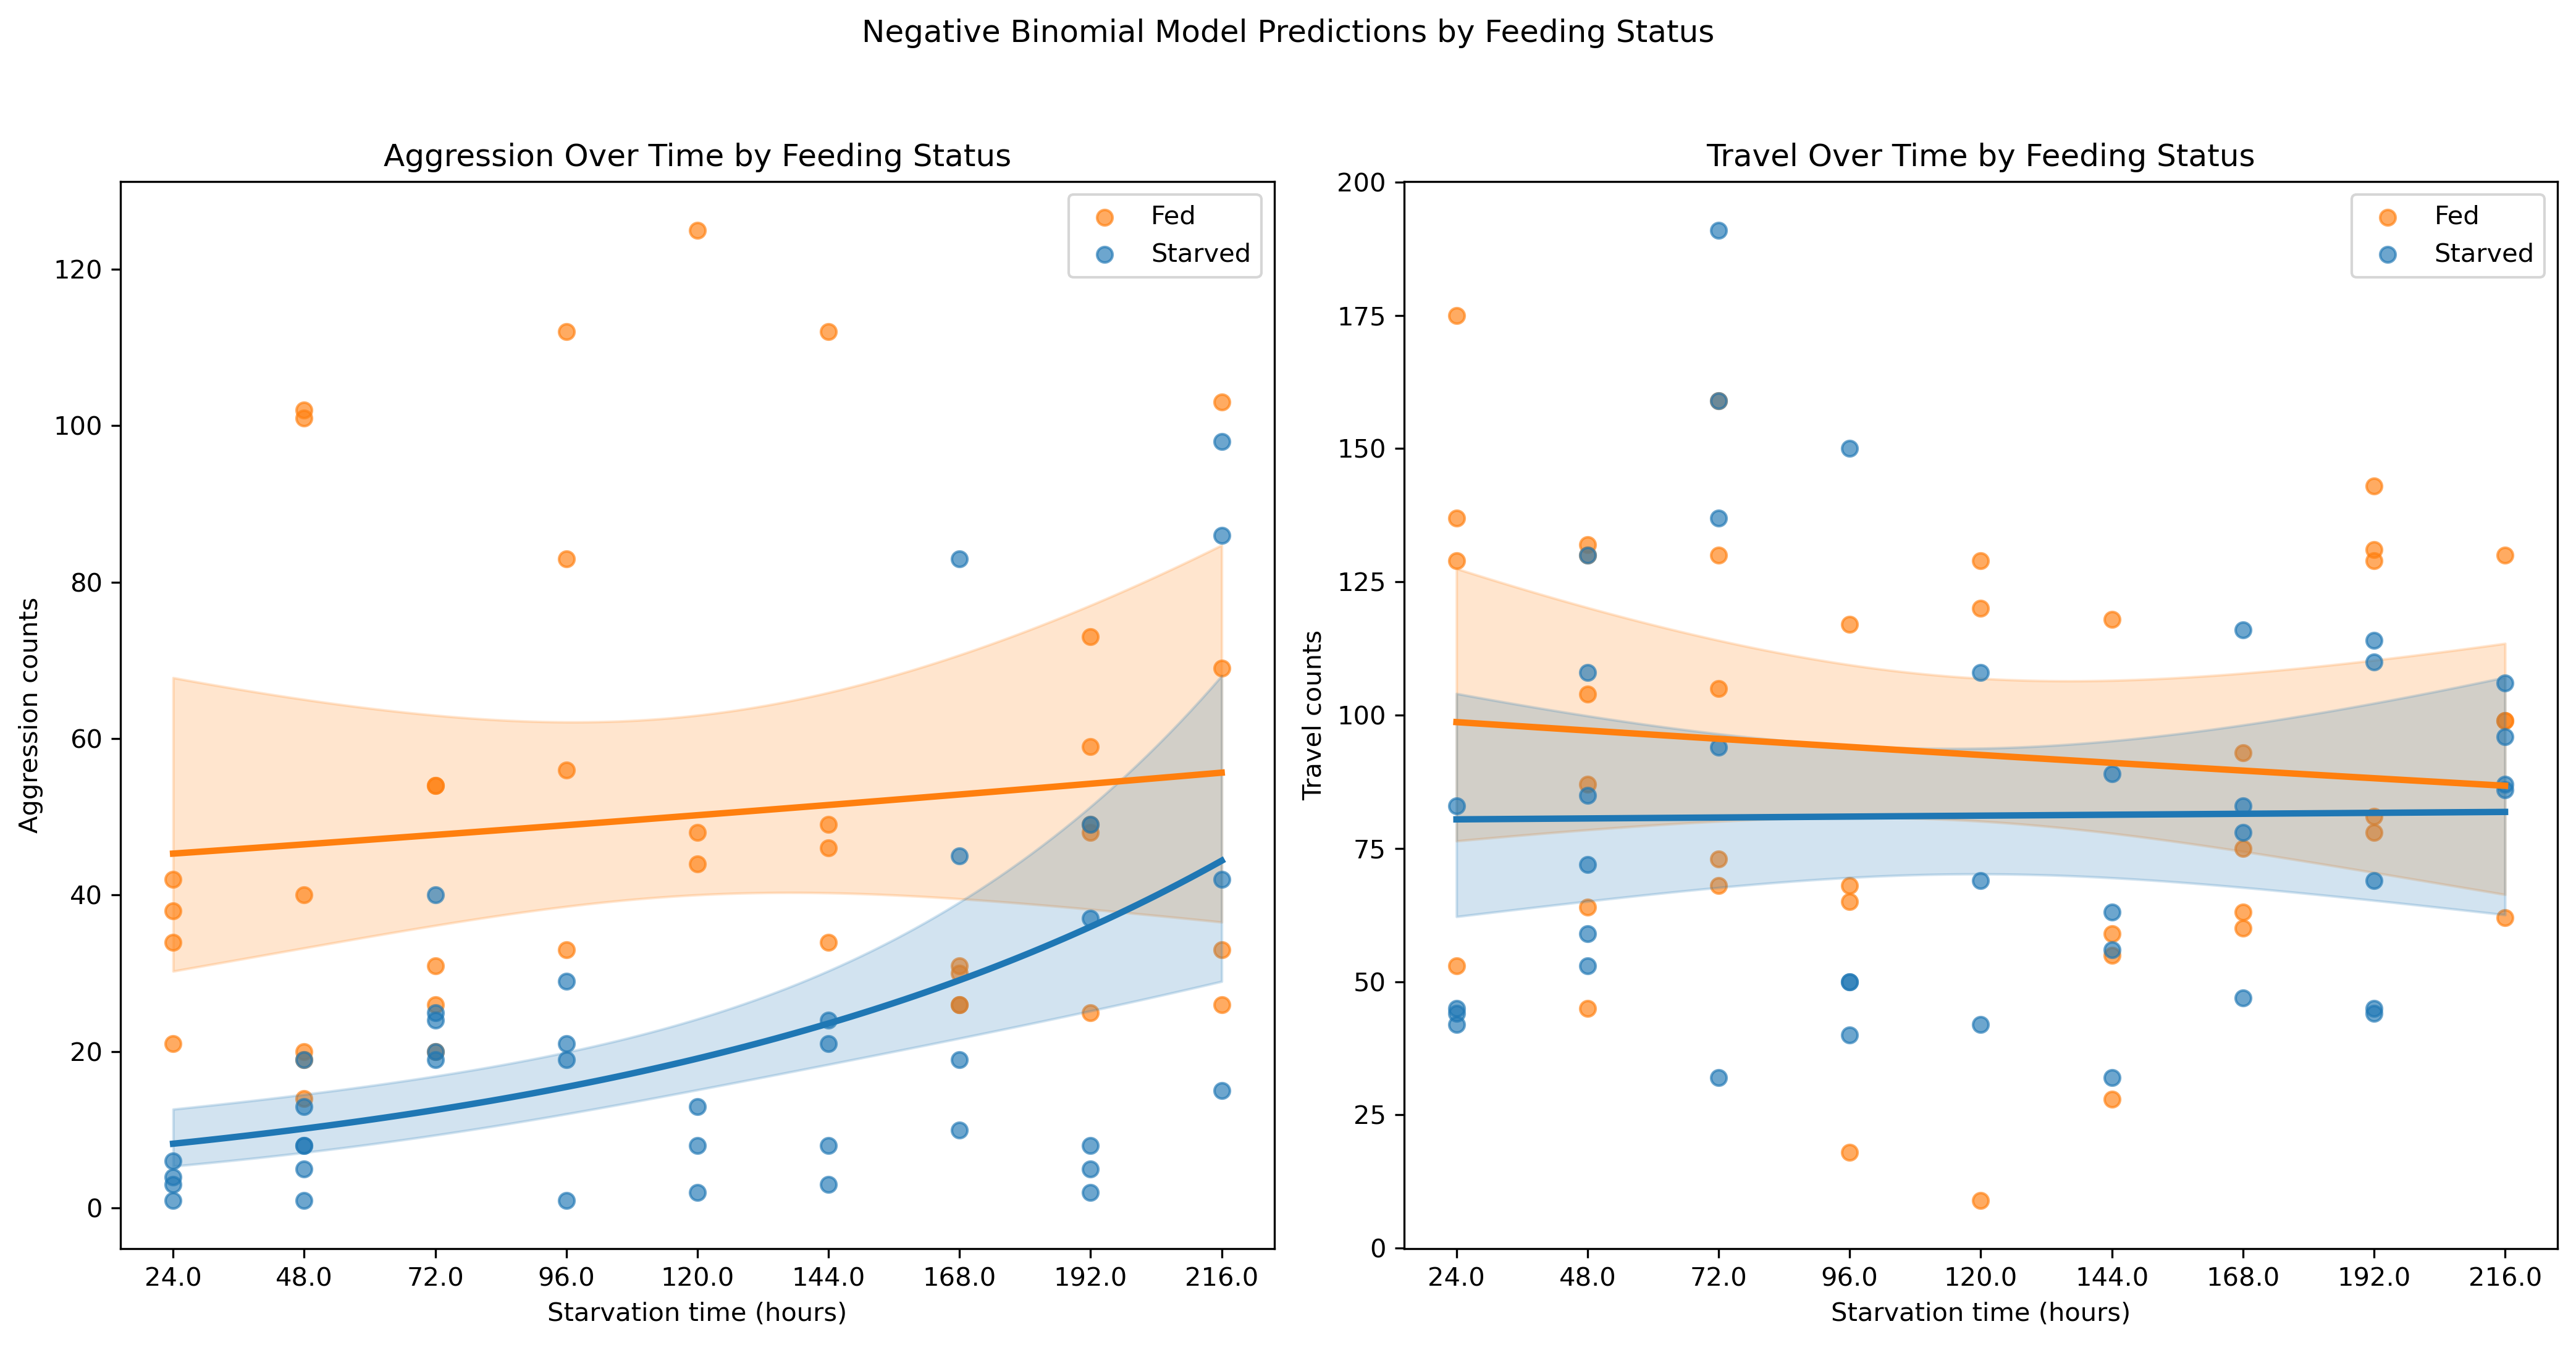

In [9]:
# Negative binomial model prediction plots for aggression and travel counts

# Outcomes and model settings
outcome_models = {
    "Aggression_Counts": {
        "alpha": 0.5,
        "title": "Aggression Over Time by Feeding Status",
        "ylabel": "Aggression counts"
    },
    "Travel_Counts": {
        "alpha": 0.2,
        "title": "Travel Over Time by Feeding Status",
        "ylabel": "Travel counts"
    }
}

# Colors
status_colors = {
    "Fed": "tab:orange",
    "Starved": "tab:blue"
}

# Create side-by-side plots
height = 7
width = 2 * height
fig, axes = plt.subplots(1,2,figsize=(width, height),dpi = 300, sharex=True)

actual_time_points = sorted(hangry_df["Time"].dropna().unique())

for ax, (outcome, settings) in zip(axes, outcome_models.items()):

    # Fit negative binomial model
    nb_model = smf.glm(f"{outcome} ~ Status * Time",data=hangry_df,family=sm.families.NegativeBinomial(alpha=settings["alpha"])).fit()

    # Create prediction grid
    time_grid = np.linspace(hangry_df["Time"].min(),hangry_df["Time"].max(),100)

    prediction_df = pd.DataFrame({
        "Time": np.tile(time_grid, hangry_df["Status"].nunique()),
        "Status": np.repeat(hangry_df["Status"].dropna().unique(),len(time_grid))})

    # Get predictions on original count scale
    pred = nb_model.get_prediction(prediction_df).summary_frame()

    prediction_df["predicted_count"] = pred["mean"]
    prediction_df["ci_lower"] = pred["mean_ci_lower"]
    prediction_df["ci_upper"] = pred["mean_ci_upper"]

    for status, status_df in hangry_df.groupby("Status"):

        color = status_colors[status]

        # Raw data
        ax.scatter(
            status_df["Time"],
            status_df[outcome],
            alpha=0.65,
            color=color,
            label=f"{status}"
        )

        # Model predictions
        status_pred = prediction_df[
            prediction_df["Status"].eq(status)
        ]

        ax.plot(
            status_pred["Time"],
            status_pred["predicted_count"],
            color=color,
            linewidth=2.5,
            label="_nolegend_"
        )

        # Confidence interval
        ax.fill_between(
            status_pred["Time"],
            status_pred["ci_lower"],
            status_pred["ci_upper"],
            color=color,
            alpha=0.2
        )

   # Label only the actual sampled time points
    ax.set_xticks(actual_time_points)
    ax.set_xticklabels(actual_time_points)

    ax.set_xlabel("Starvation time (hours)")
    ax.set_ylabel(settings["ylabel"])
    ax.set_title(settings["title"])
    ax.legend(loc="upper right")

    
fig.suptitle("Negative Binomial Model Predictions by Feeding Status",y=1.03)

plt.tight_layout()

fig.savefig("Figure 3.png",dpi=300,bbox_inches="tight")

plt.show()

# Robustness analysis

## Iterate balanced_subsample and run statistics on each resampled dataset.
* Results saved in resampling_results_df

In [10]:
######## Resample n times and run all iteration-dependent analyses ########

hangry_df = hangry_df.copy()
hangry_df["original_row_id"] = hangry_df.index

n_iterations = 1000

seen_samples = set()
duplicate_count = 0

resampling_results = []
early_late_test_results = []

# Best alpha values for negative binomial model
outcome_models = {
    "Aggression_Counts": best_alpha_aggression,
    "Travel_Counts": best_alpha_travel
}

# Early / late cutoff
time_cutoff = 144

rng = np.random.default_rng(123)

for iteration in tqdm(range(n_iterations)):

    # Draw one balanced subsample
    one_sample_df = balanced_subsample(hangry_df, rng).copy()

    # Check whether this exact subset of original rows has already been drawn
    sample_signature = tuple(sorted(one_sample_df["original_row_id"]))

    if sample_signature in seen_samples:
        duplicate_count += 1
    else:
        seen_samples.add(sample_signature)

# ------------------------------------------------------------
# 1. Negative binomial models for aggression and travel counts
# ------------------------------------------------------------

    for outcome, alpha in outcome_models.items():

        model = smf.glm(
            f"{outcome} ~ Status * Time",
            data=one_sample_df,
            family=sm.families.NegativeBinomial(alpha=alpha)
        ).fit()

        iteration_results = pd.DataFrame({
            "iteration": iteration,
            "outcome": outcome,
            "alpha": alpha,
            "term": model.params.index,
            "coef": model.params.values,
            "zvalue": model.tvalues.values,
            "pvalue": model.pvalues.values,
            "aic": model.aic,
            "dispersion": model.pearson_chi2 / model.df_resid
        })

        resampling_results.append(iteration_results)

# ------------------------------------------------------------
# 2. Early/late mean-difference tests for aggression and travel counts
# ------------------------------------------------------------
    
    test_df = one_sample_df.dropna(subset=["Time", "Status"]).copy()
    
    time_cutoff = 144
    
    test_df["time_period"] = np.where(test_df["Time"] <= time_cutoff,"Early","Late")
    
    early_late_outcomes = ["Aggression_Counts","Travel_Counts"]
    
    for outcome in early_late_outcomes:
    
        for time_period in ["Early", "Late"]:
    
            period_df = test_df[test_df["time_period"].eq(time_period)].dropna(subset=[outcome]).copy()
            fed_values = period_df.loc[period_df["Status"].eq("Fed"),outcome]
            starved_values = period_df.loc[period_df["Status"].eq("Starved"),outcome]
            test = ttest_ind(starved_values,fed_values,equal_var=False,nan_policy="omit")
    
            early_late_test_results.append({
                "iteration": iteration,
                "outcome": outcome,
                "time_cutoff": time_cutoff,
                "time_period": time_period,
                "fed_mean": fed_values.mean(),
                "starved_mean": starved_values.mean(),
                "mean_difference_starved_minus_fed": starved_values.mean() - fed_values.mean(),
                "fed_n": len(fed_values),
                "starved_n": len(starved_values),
                "t_statistic": test.statistic,
                "pvalue": test.pvalue
            })
            
# ------------------------------------------------------------
# Combine results
# ------------------------------------------------------------

resampling_results_df = pd.concat(resampling_results,ignore_index=True)

early_late_test_results_df = pd.DataFrame(early_late_test_results)

# Add rate ratios for negative binomial model summaries/plots
resampling_results_df["rate_ratio"] = np.exp(resampling_results_df["coef"])

print(f"Duplicate resampled datasets: {duplicate_count}")
print(f"Unique resampled datasets: {len(seen_samples)}")

  0%|          | 0/1000 [00:00<?, ?it/s]

Duplicate resampled datasets: 0
Unique resampled datasets: 1000


## Summarize Robustness Results (Table 3)

In [11]:
# Summarize negative binomial results across all resampled datasets
# Publication-style table for aggression and travel outcomes

# Make a copy
publication_nb_df = resampling_results_df.copy()

# Keep full model terms only
full_model_terms = [
    "Intercept",
    "Status[T.Starved]",
    "Time",
    "Status[T.Starved]:Time"
]

publication_nb_df = publication_nb_df[publication_nb_df["term"].isin(full_model_terms)].copy()

# Add exponentiated coefficients: rate ratios
publication_nb_df["rate_ratio"] = np.exp(publication_nb_df["coef"])

# Cleaner outcome labels
outcome_labels = {"Aggression_Counts": "Aggression","Travel_Counts": "Travel"}

publication_nb_df["Outcome"] = (publication_nb_df["outcome"].map(outcome_labels).fillna(publication_nb_df["outcome"]))

# Cleaner model term labels
term_labels = {
    "Intercept": "Intercept",
    "Status[T.Starved]": "Status",
    "Time": "Time",
    "Status[T.Starved]:Time": "Status × Time"
}

publication_nb_df["Model term"] = (
    publication_nb_df["term"]
    .map(term_labels)
    .fillna(publication_nb_df["term"])
)

# Define term order for display
term_order = [
    "Intercept",
    "Status",
    "Time",
    "Status × Time"
]

publication_nb_df["Model term"] = pd.Categorical(
    publication_nb_df["Model term"],
    categories=term_order,
    ordered=True
)

publication_nb_df["Outcome"] = pd.Categorical(
    publication_nb_df["Outcome"],
    categories=["Aggression", "Travel"],
    ordered=True
)

# Summarize model terms across resampled datasets
nb_publication_summary = (publication_nb_df.groupby(["Outcome", "Model term"], observed=False).agg(

        # Coefficients on log-count scale
        median_coef=("coef", "median"),
        coef_lower_95=("coef", lambda x: np.percentile(x, 2.5)),
        coef_upper_95=("coef", lambda x: np.percentile(x, 97.5)),

        # Rate ratios, exponentiated coefficients
        median_rate_ratio=("rate_ratio", "median"),
        rate_ratio_lower_95=("rate_ratio", lambda x: np.percentile(x, 2.5)),
        rate_ratio_upper_95=("rate_ratio", lambda x: np.percentile(x, 97.5)),

        # Directional consistency
        percent_coef_positive=("coef", lambda x: 100 * np.mean(x > 0)),
        percent_coef_negative=("coef", lambda x: 100 * np.mean(x < 0)),

        # Statistical consistency
        percent_p_lt_0_05=("pvalue", lambda x: 100 * np.mean(x < 0.05)),
        median_pvalue=("pvalue", "median")
    )
    .reset_index()
)

# Use the dominant direction for each term
nb_publication_summary["% same direction"] = nb_publication_summary[
    ["percent_coef_positive", "percent_coef_negative"]
].max(axis=1)

# Format coefficient and rate ratio intervals as compact publication columns
nb_publication_summary["Coefficient, median [95% RI]"] = (
    nb_publication_summary["median_coef"].map("{:.3f}".format)
    + " ["
    + nb_publication_summary["coef_lower_95"].map("{:.3f}".format)
    + ", "
    + nb_publication_summary["coef_upper_95"].map("{:.3f}".format)
    + "]"
)

nb_publication_summary["Rate ratio, median [95% RI]"] = (
    nb_publication_summary["median_rate_ratio"].map("{:.3f}".format)
    + " ["
    + nb_publication_summary["rate_ratio_lower_95"].map("{:.3f}".format)
    + ", "
    + nb_publication_summary["rate_ratio_upper_95"].map("{:.3f}".format)
    + "]"
)

# Final publication-style table
nb_publication_table = (
    nb_publication_summary[
        [
            "Outcome",
            "Model term",
            "Coefficient, median [95% RI]",
            "Rate ratio, median [95% RI]",
            "% same direction",
            "median_pvalue",
            "percent_p_lt_0_05",
        ]
    ]
    .rename(columns={
        "percent_p_lt_0_05": "% p < 0.05",
        "median_pvalue": "Median p-value"
    })
    .sort_values(["Outcome", "Model term"])
    .reset_index(drop=True)
)

# Display formatted table
display(
    nb_publication_table.style
    .format({
        "% same direction": "{:.1f}",
        "% p < 0.05": "{:.1f}",
        "Median p-value": "{:.3f}"
    })
    .hide(axis="index")
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center")
            ]
        }
    ])
)

# Optional: save table for manuscript/supplement
nb_publication_table.to_csv("Table 3.csv",index=False)

#nb_publication_table

Outcome,Model term,"Coefficient, median [95% RI]","Rate ratio, median [95% RI]",% same direction,Median p-value,% p < 0.05
Aggression,Intercept,"3.788 [3.285, 4.227]","44.172 [26.703, 68.477]",100.0,0.000,100.0
Aggression,Status,"-1.954 [-2.466, -1.370]","0.142 [0.085, 0.254]",100.0,0.000,99.9
Aggression,Time,"0.001 [-0.002, 0.004]","1.001 [0.998, 1.004]",74.1,0.597,0.7
Aggression,Status × Time,"0.008 [0.003, 0.013]","1.008 [1.003, 1.013]",100.0,0.024,68.1
Travel,Intercept,"4.612 [4.325, 4.871]","100.679 [75.598, 130.398]",100.0,0.000,100.0
Travel,Status,"-0.248 [-0.745, 0.207]","0.780 [0.475, 1.230]",84.2,0.418,7.9
Travel,Time,"-0.001 [-0.003, 0.001]","0.999 [0.997, 1.001]",79.0,0.595,0.0
Travel,Status × Time,"0.001 [-0.002, 0.004]","1.001 [0.998, 1.004]",75.1,0.575,0.6


## Visualize Robustness Results

 ### Z-Value Distribution for each Model Term (Supplementary Fig 1)

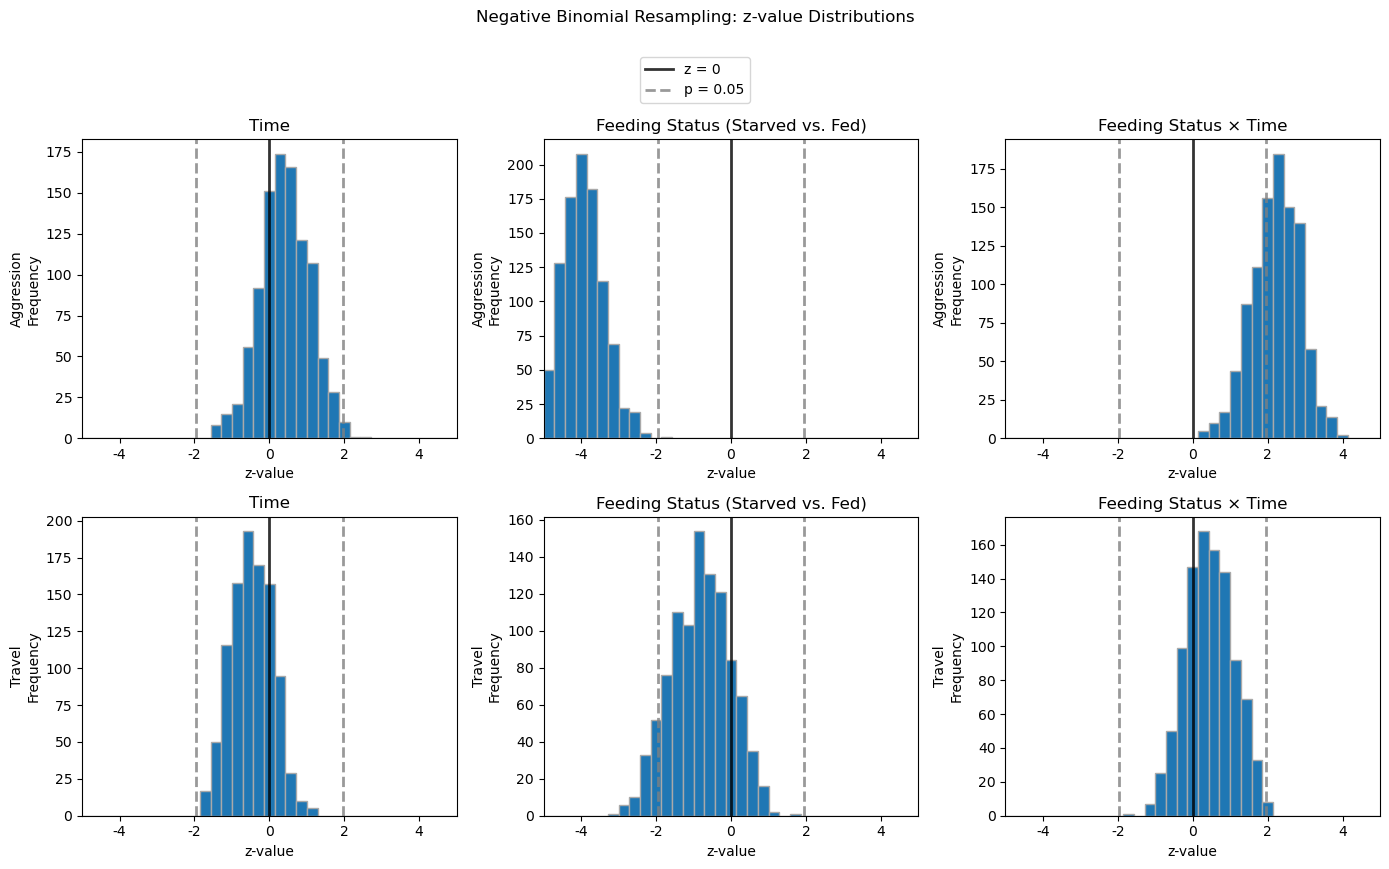

In [12]:
### Z-value histograms for negative binomial model terms ###

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Full model terms only
full_model_terms = [
    "Intercept",
    "Status[T.Starved]",
    "Time",
    "Status[T.Starved]:Time"
]

full_model_results = resampling_results_df[
    resampling_results_df["term"].isin(full_model_terms)
].copy()

def clean_decimal(x, pos):
    return f"{x:.2f}".rstrip("0").rstrip(".")

# Terms to plot, excluding intercept
plot_model_terms = [
    "Time",
    "Status[T.Starved]",
    "Status[T.Starved]:Time"
]

term_titles = {
    "Status[T.Starved]": "Feeding Status (Starved vs. Fed)",
    "Time": "Time",
    "Status[T.Starved]:Time": "Feeding Status × Time"
}

outcome_titles = {
    "Aggression_Counts": "Aggression",
    "Travel_Counts": "Travel"
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)

for row_idx, outcome in enumerate(["Aggression_Counts", "Travel_Counts"]):

    outcome_df = full_model_results[full_model_results["outcome"].eq(outcome)]

    for ax, term in zip(axes[row_idx], plot_model_terms):

        term_df = outcome_df[outcome_df["term"].eq(term)]
        zvals = term_df["zvalue"].dropna()

        ax.xaxis.set_major_formatter(FuncFormatter(clean_decimal))

        ax.hist(zvals, bins=35, range=(-5, 5), edgecolor="darkgray")

        ax.axvline(0, linestyle="-", linewidth=2, color="black", alpha=0.8, label="z = 0")
        ax.axvline(-1.96, linestyle="--", linewidth=2, color="gray", alpha=0.8, label="p = 0.05")
        ax.axvline(1.96, linestyle="--", linewidth=2, color="gray", alpha=0.8)

        ax.set_xlim(-5, 5)

        ax.set_title(term_titles[term])
        ax.set_xlabel("z-value")
        ax.set_ylabel(f"{outcome_titles[outcome]}\nFrequency")

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.03))

fig.suptitle("Negative Binomial Resampling: z-value Distributions", y=1.08)

plt.tight_layout()

fig.savefig("Supplemental Figure 1.png", dpi=300, bbox_inches="tight")

plt.show()

 ### P-Value Distribution for each Model Term

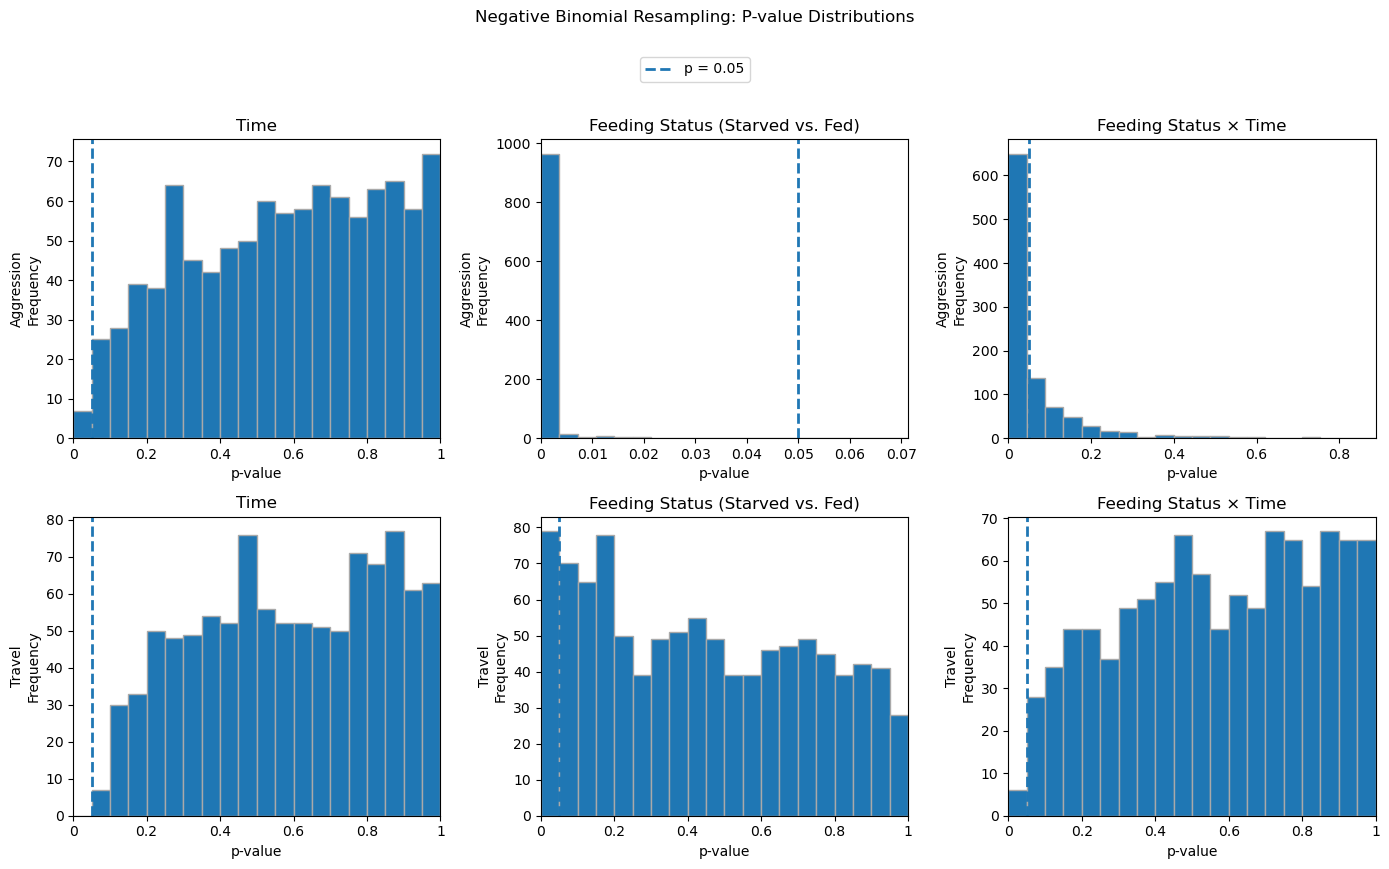

In [13]:
### P-value histograms for negative binomial model terms ###

# Make sure full_model_results exists
full_model_terms = ["Intercept","Status[T.Starved]","Time","Status[T.Starved]:Time"]

full_model_results = resampling_results_df[resampling_results_df["term"].isin(full_model_terms)].copy()

def clean_decimal(x, pos):
    return f"{x:.6f}".rstrip("0").rstrip(".")

# Terms to plot, excluding intercept
plot_model_terms = ["Time","Status[T.Starved]","Status[T.Starved]:Time"]
term_titles = {"Status[T.Starved]": "Feeding Status (Starved vs. Fed)","Time": "Time","Status[T.Starved]:Time": "Feeding Status × Time"}
outcome_titles = {"Aggression_Counts": "Aggression","Travel_Counts": "Travel"}
fig, axes = plt.subplots(2,3,figsize=(14, 8),sharey=False)

for row_idx, outcome in enumerate(["Aggression_Counts", "Travel_Counts"]):

    outcome_df = full_model_results[full_model_results["outcome"].eq(outcome)]

    for ax, term in zip(axes[row_idx], plot_model_terms):

        term_df = outcome_df[outcome_df["term"].eq(term)]

        pvals = term_df["pvalue"].dropna()

        ax.xaxis.set_major_formatter(FuncFormatter(clean_decimal))

        # If no p-values exist, label the panel and skip histogram
        if len(pvals) == 0:
            ax.text(0.5,0.5,"No p-values found",ha="center",va="center",transform=ax.transAxes)
            ax.set_title(term_titles[term])
            ax.set_xlabel("p-value")
            ax.set_ylabel(f"{outcome_titles[outcome]}\nFrequency")
            continue

        # Let each subplot choose its own x-axis based on its p-values
        x_min = 0
        x_max = pvals.max()

        # Add a little padding so the largest value is not on the edge
        x_max = min(1, x_max * 1.05)

        # Avoid a zero-width axis if all p-values are 0
        if x_max == 0:
            x_max = 0.001

        ax.hist(pvals,bins=20,range=(x_min, x_max),edgecolor="darkgray")

        # Only draw p = 0.05 line if visible on this subplot
        if x_max >= 0.05:
            ax.axvline(0.05,linestyle="--",linewidth=2,label="p = 0.05")

        ax.set_xlim(x_min, x_max)
        ax.set_title(term_titles[term])
        ax.set_xlabel("p-value")
        ax.set_ylabel(f"{outcome_titles[outcome]}\nFrequency")

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(handles,labels,loc="upper center",bbox_to_anchor=(0.5, 1.03))

fig.suptitle("Negative Binomial Resampling: P-value Distributions",y=1.08)

plt.tight_layout()

fig.savefig("negative_binomial_pvalue_distributions.png",dpi=300,bbox_inches="tight")

plt.show()

 ### Rate-ratio Distribution for each Model Term (Supplementary Figure 2)

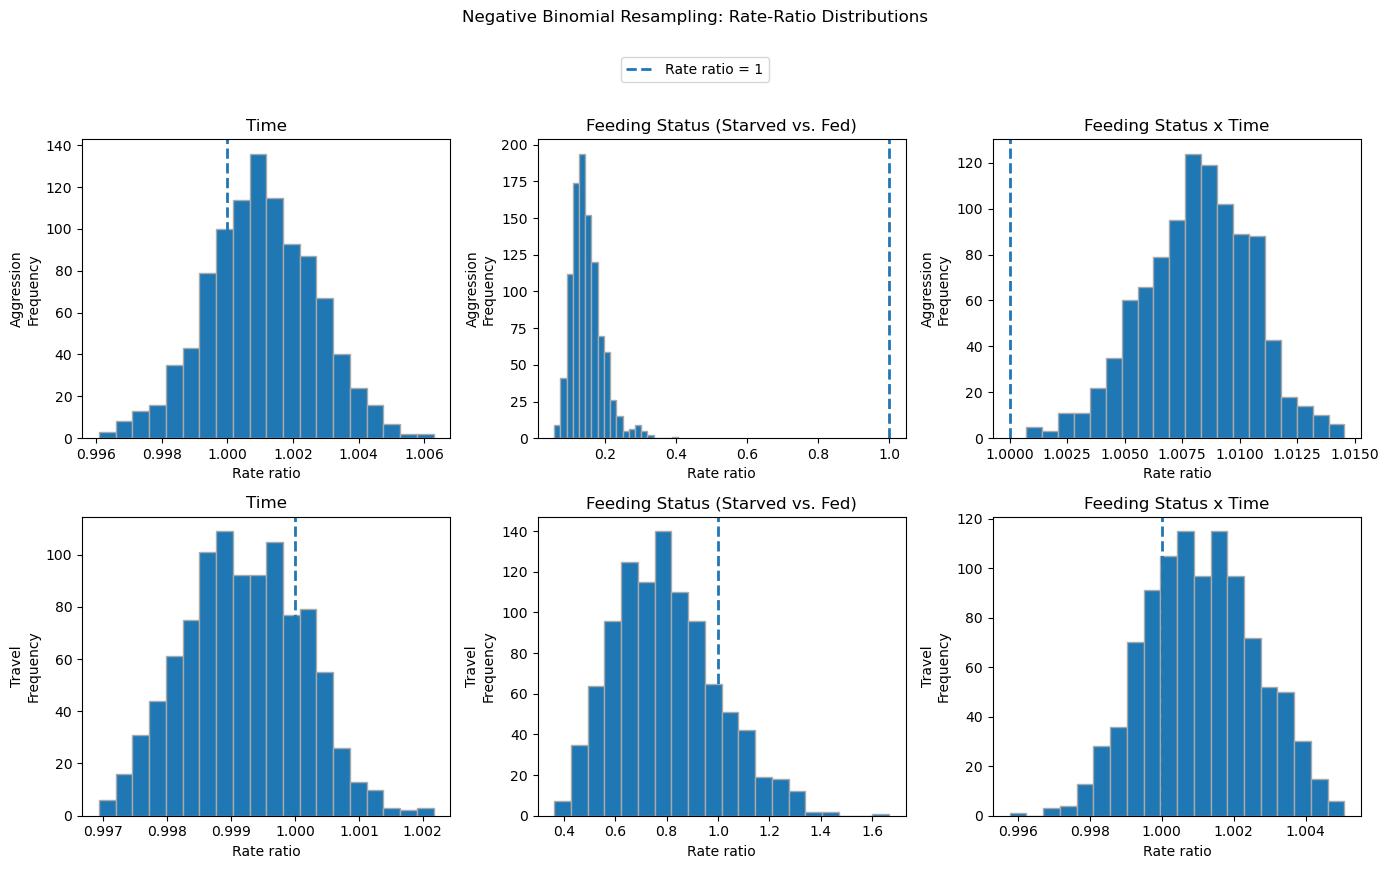

In [14]:
### Rate-ratio histograms for negative binomial model terms ###

# Terms to plot, excluding intercept
plot_model_terms = ["Time","Status[T.Starved]","Status[T.Starved]:Time"]

term_titles = {"Status[T.Starved]": "Feeding Status (Starved vs. Fed)","Time": "Time","Status[T.Starved]:Time": "Feeding Status x Time"}

outcome_titles = {"Aggression_Counts": "Aggression","Travel_Counts": "Travel"}

fig, axes = plt.subplots(2,3,figsize=(14, 8),sharey=False)

for row_idx, outcome in enumerate(["Aggression_Counts", "Travel_Counts"]):

    outcome_df = full_model_results[full_model_results["outcome"].eq(outcome)]

    for ax, term in zip(axes[row_idx], plot_model_terms):

        term_df = outcome_df[outcome_df["term"].eq(term)]

        rate_ratios = term_df["rate_ratio"].dropna()

        ax.hist(rate_ratios,bins=20,edgecolor="darkgray")

        # Rate ratio of 1 means no effect
        ax.axvline(1,linestyle="--",linewidth=2,label="Rate ratio = 1")
        ax.set_title(term_titles[term])
        ax.set_xlabel("Rate ratio")
        ax.set_ylabel(f"{outcome_titles[outcome]}\nFrequency")

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(handles,labels,loc="upper center",bbox_to_anchor=(0.5, 1.03))

fig.suptitle("Negative Binomial Resampling: Rate-Ratio Distributions",y=1.08)

plt.tight_layout()

fig.savefig("Supplemental Figure 2.png", dpi=300, bbox_inches="tight")

plt.show()

# Difference between Starved and Fed Aggression before and after 144 hours (6 days)

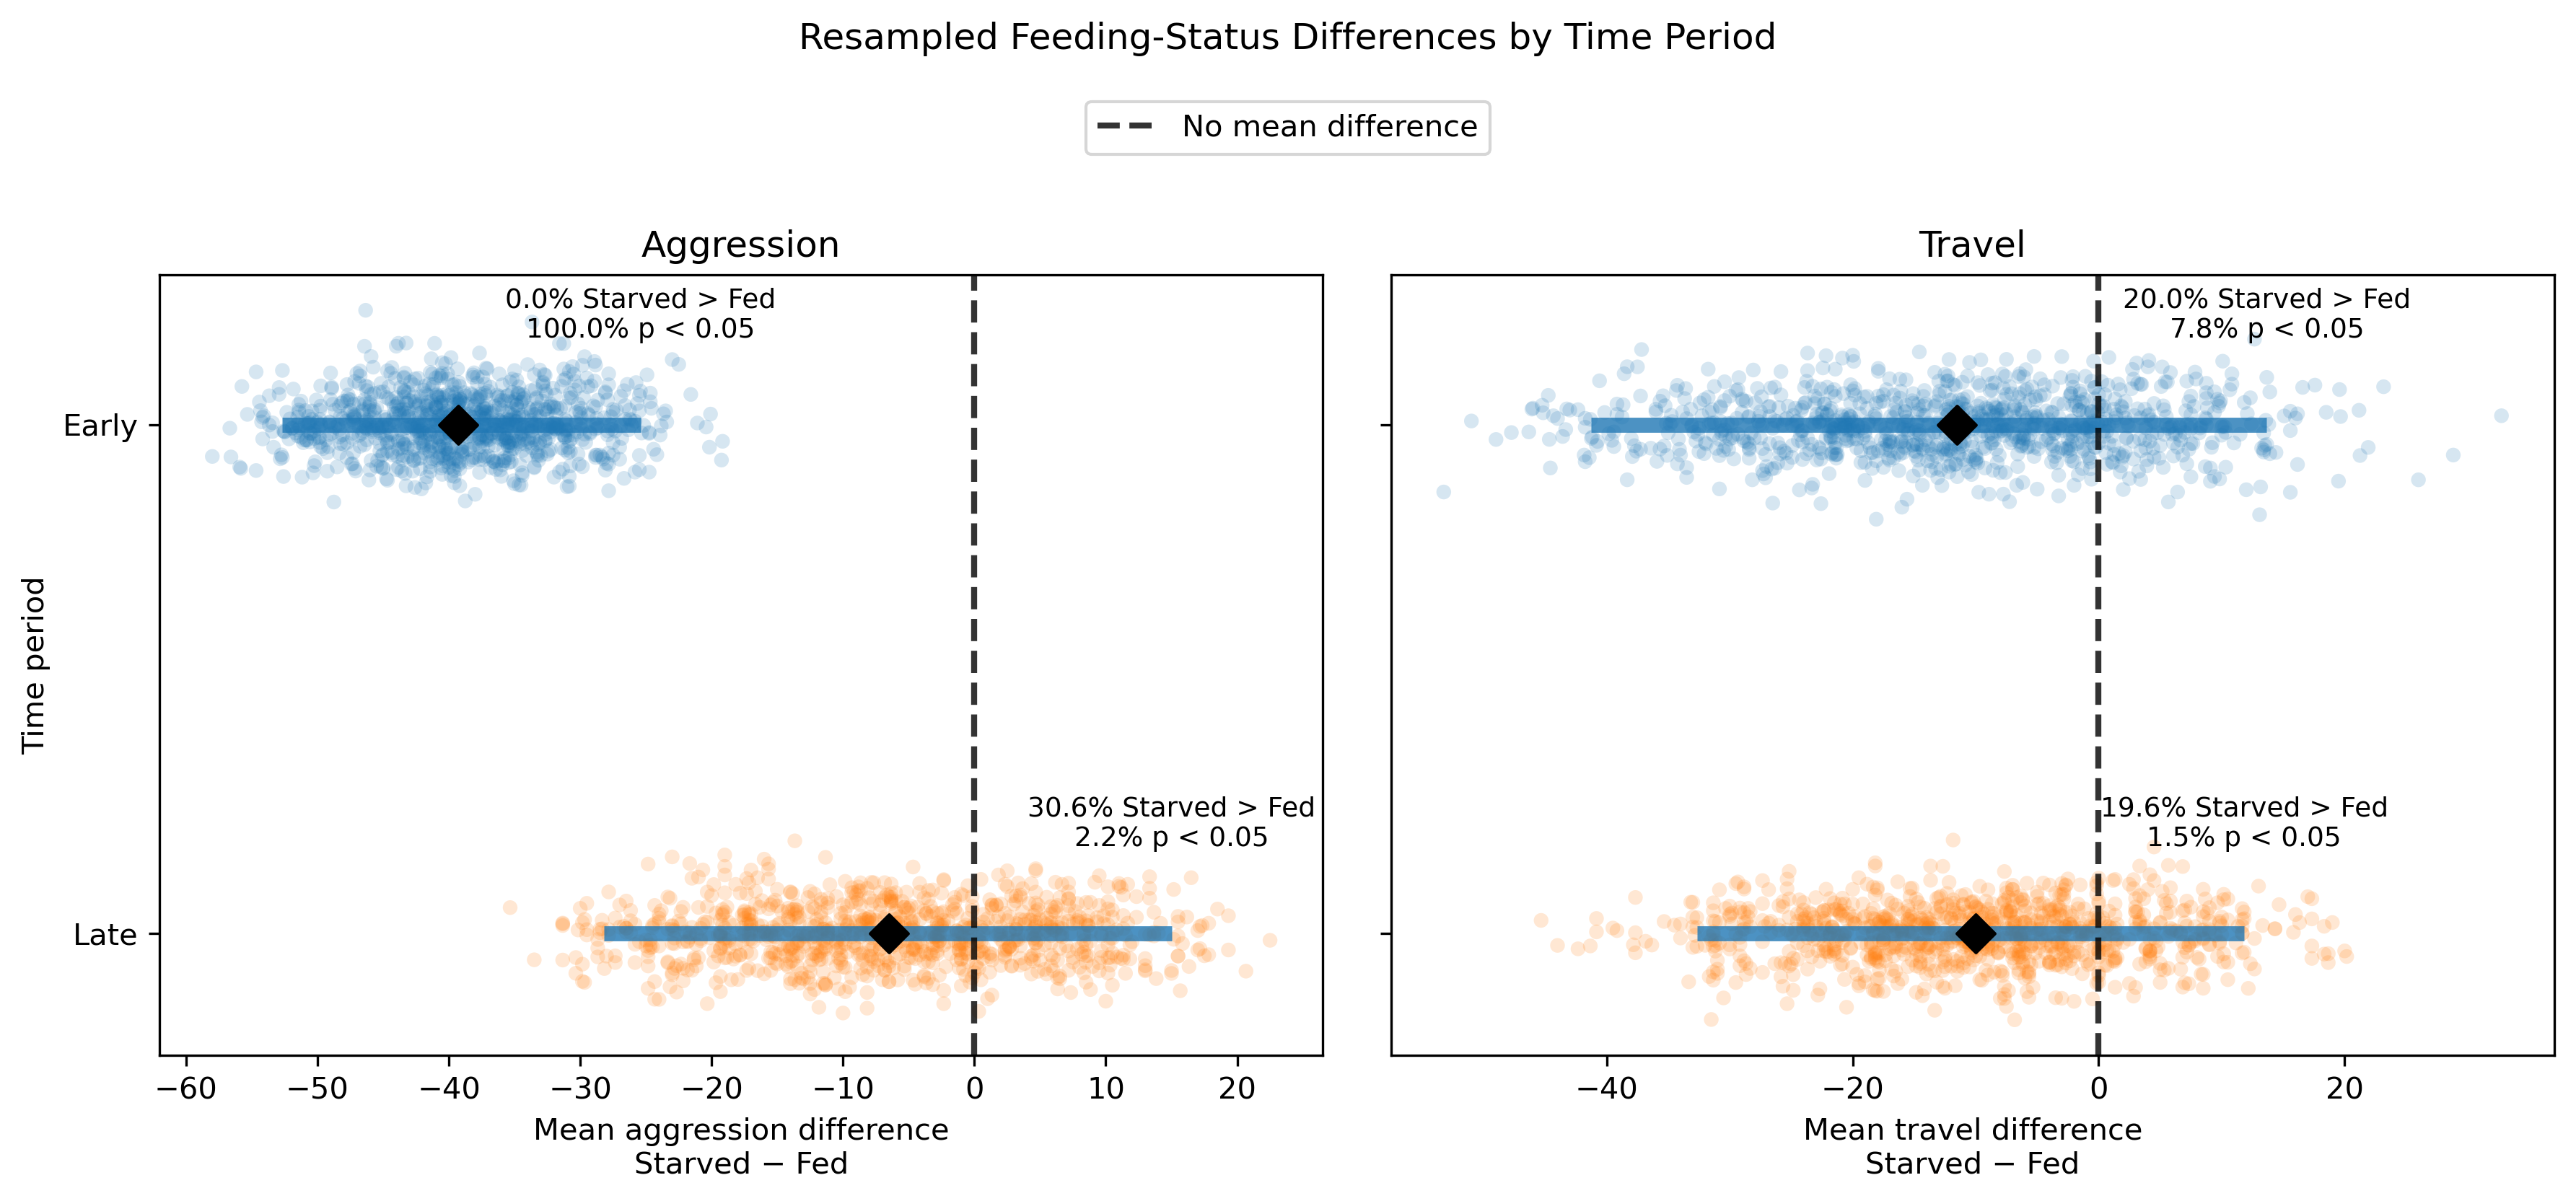

In [15]:
##########  Visualization of resampled early/late mean differences
# Difference = Starved mean - Fed mean

plot_df = early_late_test_results_df.copy()

outcome_order = ["Aggression_Counts", "Travel_Counts"]

outcome_titles = {
    "Aggression_Counts": "Aggression",
    "Travel_Counts": "Travel"
}

x_axis_labels = {
    "Aggression_Counts": "Mean aggression difference\nStarved − Fed",
    "Travel_Counts": "Mean travel difference\nStarved − Fed"
}

period_order = ["Early", "Late"]

plot_df["time_period"] = pd.Categorical(plot_df["time_period"], categories=period_order, ordered=True)
plot_df["outcome"] = pd.Categorical(plot_df["outcome"], categories=outcome_order, ordered=True)

summary_df = (
    plot_df
    .groupby(["outcome", "time_period"], observed=False)
    .agg(
        median_difference=("mean_difference_starved_minus_fed", "median"),
        lower_difference=("mean_difference_starved_minus_fed", lambda x: np.percentile(x.dropna(), 2.5)),
        upper_difference=("mean_difference_starved_minus_fed", lambda x: np.percentile(x.dropna(), 97.5)),
        percent_starved_gt_fed=("mean_difference_starved_minus_fed", lambda x: 100 * np.mean(x.dropna() > 0)),
        percent_p_lt_0_05=("pvalue", lambda x: 100 * np.mean(x.dropna() < 0.05))
    )
    .reset_index()
)

y_positions = {"Early": 1, "Late": 0}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300, sharey=True)

rng = np.random.default_rng(1234)

for ax, outcome in zip(axes, outcome_order):

    outcome_df = plot_df[plot_df["outcome"].eq(outcome)].copy()
    outcome_summary = summary_df[summary_df["outcome"].eq(outcome)].copy()

    for time_period in period_order:

        period_df = outcome_df[outcome_df["time_period"].eq(time_period)].copy()

        x = period_df["mean_difference_starved_minus_fed"].dropna().values
        y_base = y_positions[time_period]
        y = y_base + rng.normal(0, 0.055, size=len(x))

        ax.scatter(x, y, alpha=0.18, s=24, edgecolor="none", label="_nolegend_")

        row = outcome_summary[outcome_summary["time_period"].eq(time_period)].iloc[0]

        ax.hlines(y=y_base, xmin=row["lower_difference"], xmax=row["upper_difference"], linewidth=5, alpha=0.8)
        ax.scatter(row["median_difference"], y_base, color="black", s=80, marker="D", zorder=5, label="_nolegend_")

        ax.text(
            row["upper_difference"],
            y_base + 0.16,
            f'{row["percent_starved_gt_fed"]:.1f}% Starved > Fed\n{row["percent_p_lt_0_05"]:.1f}% p < 0.05',
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.axvline(0, linestyle="--", linewidth=2, color="black", alpha=0.8, label="No mean difference")
    ax.set_yticks([y_positions[p] for p in period_order])
    ax.set_yticklabels(period_order)
    ax.set_xlabel(x_axis_labels[outcome])
    ax.set_title(outcome_titles[outcome])

axes[0].set_ylabel("Time period")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.04))

fig.suptitle("Resampled Feeding-Status Differences by Time Period", y=1.10)

plt.tight_layout()

fig.savefig("Figure 4.png", dpi=300, bbox_inches="tight")

plt.show()

# Software Package Versions

In [17]:
import sys
import importlib.metadata as metadata

packages = [
    "numpy",
    "pandas",
    "statsmodels",
    "scipy",
    "matplotlib",
    "tqdm"
]

print(f"Python: {sys.version.split()[0]}")

for package in packages:
    print(f"{package}: {metadata.version(package)}")

Python: 3.12.2
numpy: 1.26.4
pandas: 2.2.2
statsmodels: 0.14.2
scipy: 1.13.1
matplotlib: 3.8.4
tqdm: 4.66.4
